In [2]:
import torch
import torch.nn as nn

import torch_geometric as tg
import torch_geometric.utils as tgu
import torch_geometric.nn as tgnn
import matplotlib.pyplot as plt

import numpy as np

## Notes from graphcast
 - there are multiple layers of nodes -> some nodes propagate information to more distant nodes
 - loss function takes into account multiple factors - e.g. sample density
 - autoregressive training 
   - model is trained using fix interval
   - to predict more distant (in time) points then previous prediction of a model is used
   - predicting 10 day ahead tends to have large overfitting
 - gnn was selected because weather function is the same in every place of the globe

In [3]:
omega = 1.8

feature_vec_len = 8
x = np.arange(0,6.4,0.1).reshape((-1,1))
t = np.arange(0,6,0.1).reshape([-1,1])

values = np.sin(omega*t+x.T)

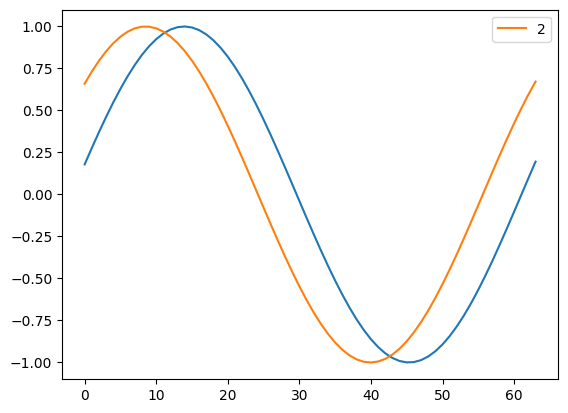

In [4]:
plt.plot(values[1,:])
plt.plot(values[4,:], label='2')
plt.legend()

In [5]:
def get_sample(values, dt=4, inclusion_prob=0.5):
    time_horizon, positions = values.shape

    fully_connected_adj = torch.ones(positions, positions)
    fully_connected = tgu.dense_to_sparse(fully_connected_adj)[0]

    sample = []
    sample_dt = []

    time_stamp = np.random.randint(time_horizon - dt)

    is_included = np.random.random(positions) < inclusion_prob
    for idx, included in zip(range(positions), is_included):
        sample.append((
            idx/positions,
            included*1.0,
            values[time_stamp, idx] * included,
        ))
        sample_dt.append((
            idx/positions,
            1.0,
            values[time_stamp + dt, idx],
        ))

    return (
        torch.tensor(sample, dtype=torch.float32, requires_grad=False),
        torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),
        torch.tensor(sample_dt, dtype=torch.float32, requires_grad=False)
    )

In [6]:
class feature_encoder(nn.Module):
    def __init__(self, dims=None, output_feature_num=feature_vec_len):
        nn.Module.__init__(self)

        if dims is None:
            self.dims = {
                "time": 1,
                "x_pos": 1,
                "value": 1,
            } 
        else:
            self.dims = dims

        self.input_dimensionality = sum(self.dims.values())

        self.seq = nn.Sequential(
            nn.Linear(self.input_dimensionality, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
            nn.Linear(32, output_feature_num),
            nn.Tanh()
        )

    def forward(self, x):
        return self.seq(x)

In [7]:
fe_model = feature_encoder()
te = feature_encoder({'time': 1}, output_feature_num=16)
sample = get_sample(values)
fe_model(sample[0])

/tmp/ipykernel_41/3835534236.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


tensor([[-0.1102, -0.1277,  0.2179,  0.0120,  0.2061, -0.1133,  0.1076,  0.0502],
        [-0.1107, -0.1266,  0.2189,  0.0125,  0.2054, -0.1130,  0.1073,  0.0499],
        [-0.1379, -0.1258,  0.3102,  0.0092,  0.2247, -0.0897,  0.0997,  0.0236],
        [-0.1398, -0.1310,  0.3076,  0.0079,  0.2286, -0.0915,  0.1020,  0.0286],
        [-0.1123, -0.1230,  0.2220,  0.0141,  0.2035, -0.1120,  0.1064,  0.0492],
        [-0.1128, -0.1219,  0.2230,  0.0146,  0.2029, -0.1116,  0.1061,  0.0490],
        [-0.1133, -0.1207,  0.2240,  0.0152,  0.2023, -0.1112,  0.1057,  0.0487],
        [-0.1139, -0.1195,  0.2251,  0.0157,  0.2017, -0.1108,  0.1054,  0.0484],
        [-0.1144, -0.1183,  0.2262,  0.0162,  0.2011, -0.1104,  0.1051,  0.0481],
        [-0.1587, -0.1626,  0.3052, -0.0041,  0.2526, -0.1041,  0.1187,  0.0437],
        [-0.1626, -0.1673,  0.3065, -0.0064,  0.2562, -0.1061,  0.1215,  0.0442],
        [-0.1664, -0.1717,  0.3081, -0.0087,  0.2595, -0.1081,  0.1241,  0.0442],
        [-0.1702

In [8]:
# x_cord, y_cord, time
# time_embed 


class gnn_model(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.gnn_out_ch = 32
        self.edge_vector_len = 16
        edge_params_shape = values.shape[1]**2
        #self.fe = feature_encoder()
        self.edge_params = nn.Parameter(torch.randn([edge_params_shape, self.edge_vector_len])/20)

        self.l1 = tgnn.GAT(
            in_channels=3,#feature_vec_len,
            hidden_channels=4*feature_vec_len,
            num_layers=3,
            out_channels=self.gnn_out_ch,
            dropout=0.1,
            act='gelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )
        self.l2 = nn.Linear(self.gnn_out_ch, 2)

    def forward(self, nodes, edges):
        encoded_features = nodes#self.fe(nodes)

        g_output = self.l1(encoded_features, edges, edge_attr=self.edge_params)
        dense_output = self.l2(g_output)

        return dense_output



In [9]:
model = gnn_model()

In [10]:
model(
    sample[0],
    sample[1],
).shape

torch.Size([64, 2])

In [11]:
sample[1][0]

tensor([ 0,  0,  0,  ..., 63, 63, 63])

In [12]:
NUM_TR_STEPS = 1024*32
loss_t_0 = []
loss_t_dt = []
optimizer = torch.optim.AdamW(model.parameters(),lr=1e-2,)
loss_fn = nn.MSELoss()

for i in range(NUM_TR_STEPS):
    sample = get_sample(values)

    y_hat = model(
        sample[0],
        sample[1],
    )

    loss = loss_fn(sample[2][:,-1:], y_hat[:,-1:])
    
    # check if this is correct place for zero grad
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i%10 == 0:
        l_dt = ((sample[2][:,-1] - y_hat[:,-1])**2).T
        loss_t_dt.append(l_dt.detach())
        print(f"l_dt:{torch.mean(l_dt)}")



/tmp/ipykernel_41/3835534236.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),
/tmp/ipykernel_41/910214439.py:23: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  l_dt = ((sample[2][:,-1] - y_hat[:,-1])**2).T


l_dt:0.526070773601532
l_dt:0.5072813630104065
l_dt:0.49678459763526917
l_dt:0.5077780485153198
l_dt:0.4929400384426117
l_dt:0.4929980933666229
l_dt:0.505400538444519
l_dt:0.4904882609844208
l_dt:0.4995103180408478
l_dt:0.49543634057044983
l_dt:0.5111685991287231
l_dt:0.5062350630760193
l_dt:0.49321573972702026
l_dt:0.506381094455719
l_dt:0.5020012259483337
l_dt:0.49362608790397644
l_dt:0.5007108449935913
l_dt:0.4945054054260254
l_dt:0.5036488175392151
l_dt:0.3072526752948761
l_dt:0.4792039394378662
l_dt:0.5908321738243103
l_dt:0.3185114860534668
l_dt:0.4209989309310913
l_dt:0.3253743648529053
l_dt:0.18464066088199615
l_dt:0.15423211455345154
l_dt:0.046536803245544434
l_dt:0.24306809902191162
l_dt:0.18738602101802826
l_dt:0.044647324830293655
l_dt:0.016563180834054947
l_dt:0.055000945925712585
l_dt:0.01981494203209877
l_dt:0.06699363887310028
l_dt:0.040285512804985046
l_dt:0.023129217326641083
l_dt:0.055207304656505585
l_dt:0.03228679299354553
l_dt:0.025748759508132935
l_dt:0.054166130

KeyboardInterrupt: 

In [13]:
torch.mean((
    #y_hat[:,-1:] - sample[2][:,-1:])**2)
    sample[0][:,-1:] - sample[2][:,-1:])**2)

tensor(0.3494)

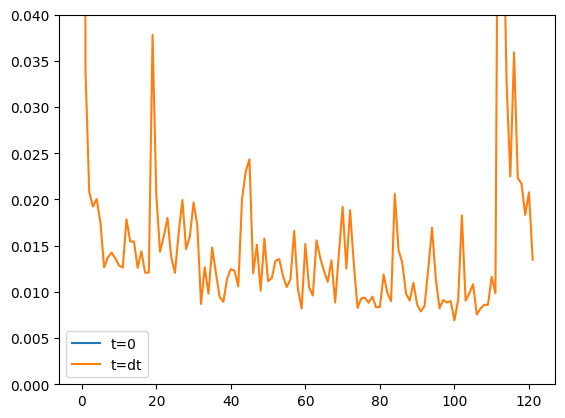

In [14]:
mean_over = 20
t0 = np.array([torch.mean(x).item() for x in loss_t_0])
t0_mean = t0[t0.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

t_dt = np.array([torch.mean(x).item() for x in loss_t_dt])
t_dt_mean = t_dt[t_dt.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

plt.plot(t0_mean, label='t=0')
plt.plot(t_dt_mean, label='t=dt')
plt.legend()
plt.ylim(0.0,.04)
plt.show()

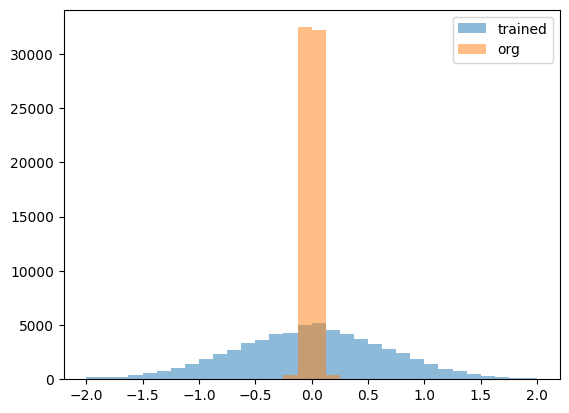

In [15]:
plt.hist(model.edge_params.detach().flatten(), bins=32, label='trained', alpha=0.5,range=(-2,2))
plt.hist((torch.randn(model.edge_params.shape)/20).flatten(), bins=32, label='org', alpha=0.5,range=(-2,2))
plt.legend()
plt.show()

In [28]:
NUM_TEST_STEPS = 64
res_dict = {}

with torch.no_grad():
    for inc_prob in [.05,.1,.2,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(values,inclusion_prob=0.2)

            y_hat = model(
                sample[0],
                sample[1],
            )

            l_dt = ((sample[2][:,-1] - y_hat[:,-1])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

/tmp/ipykernel_41/3835534236.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


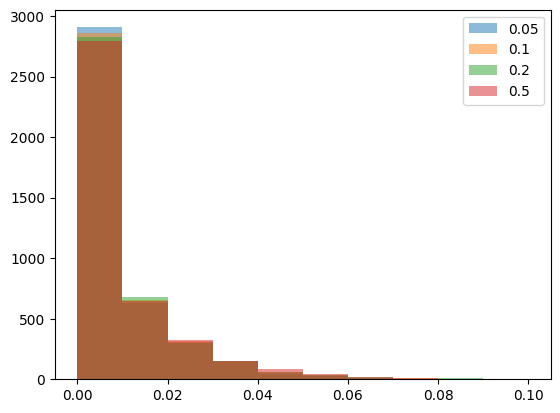

In [30]:
for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,0.1), alpha=0.5, label=str(label))
plt.legend()
plt.show()

In [22]:
sample[0].shape

torch.Size([64, 3])